# 2D latent GAN sample

Generate categorical 2D images with the trained WGAN generator and inspect the fixed critic scores.

In [6]:
from argparse import Namespace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.app.runtime import (
    build_dataset,
    build_loader,
    load_defaults,
    load_predictor,
    load_run_generator,
    load_run_vae,
)
from src.modeling.phases import (
    probabilities_to_calibrated_labels,
    probabilities_to_labels,
)

## Parameters

In [7]:
RUN_DIR = "run/20260714-212941-630628"
DIFFUSION_RUN_DIR = "run/20260714-204642-744006"
BATCH_SIZE = 4
DIFFUSION_BATCH_SIZE = 16
DISPLAY_COUNT = 4

## Generate

In [8]:
run_dir = Path(RUN_DIR) if RUN_DIR else max(
    [p for p in (ROOT / "run").glob("*") if (p / "gan.yaml").is_file()],
    key=lambda p: p.stat().st_mtime,
)
run_dir = run_dir if run_dir.is_absolute() else ROOT / run_dir
diffusion_run_dir = Path(DIFFUSION_RUN_DIR) if DIFFUSION_RUN_DIR else max(
    [p for p in (ROOT / "run").glob("*") if (p / "diffusion.yaml").is_file()],
    key=lambda p: p.stat().st_mtime,
)
diffusion_run_dir = (
    diffusion_run_dir
    if diffusion_run_dir.is_absolute()
    else ROOT / diffusion_run_dir
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args = Namespace(**load_defaults(run_dir / "gan.yaml"))
args.data_dir = Path(args.data_dir)
args.data_dir = args.data_dir if args.data_dir.is_absolute() else ROOT / args.data_dir
args.batch_size = BATCH_SIZE

dataset = build_dataset(args)
real_images, _ = next(build_loader(dataset, args, device=torch.device("cpu")))
real_images = real_images.to(device)
vae = load_run_vae(run_dir, device)
generator = load_run_generator(run_dir, device)
diffusion_predictor = load_predictor(
    diffusion_run_dir, diffusion_run_dir, run_dir, device=device
)
critic = diffusion_predictor.critic

with torch.no_grad():
    real_latent, _ = vae.encode(real_images)
    noise = torch.randn(BATCH_SIZE, args.noise_ch, device=device)
    fake_latent = generator(noise)
    probabilities = vae.decode_probs(fake_latent)
    generated = probabilities_to_labels(probabilities, args.num_phases)
    real_scores = critic(real_latent)
    fake_scores = critic(fake_latent)

real_fraction = F.one_hot(real_images[:, 0].long(), num_classes=args.num_phases).float().mean(dim=(0, 1, 2))
generated_fraction = F.one_hot(generated[:, 0], num_classes=args.num_phases).float().mean(dim=(0, 1, 2))
print("run:", run_dir)
print("diffusion run:", diffusion_run_dir)
print("device:", device)
print("real fraction:", [round(value, 4) for value in real_fraction.tolist()])
print("generated fraction:", [round(value, 4) for value in generated_fraction.tolist()])
print(f"critic real: {real_scores.mean().item():.4f}")
print(f"critic generated: {fake_scores.mean().item():.4f}")

run: d:\code\microlad\run\20260714-212941-630628
diffusion run: d:\code\microlad\run\20260714-204642-744006
device: cuda
real fraction: [0.265, 0.1411, 0.594]
generated fraction: [0.326, 0.1011, 0.5729]
critic real: 47.6905
critic generated: 45.7399


## Check

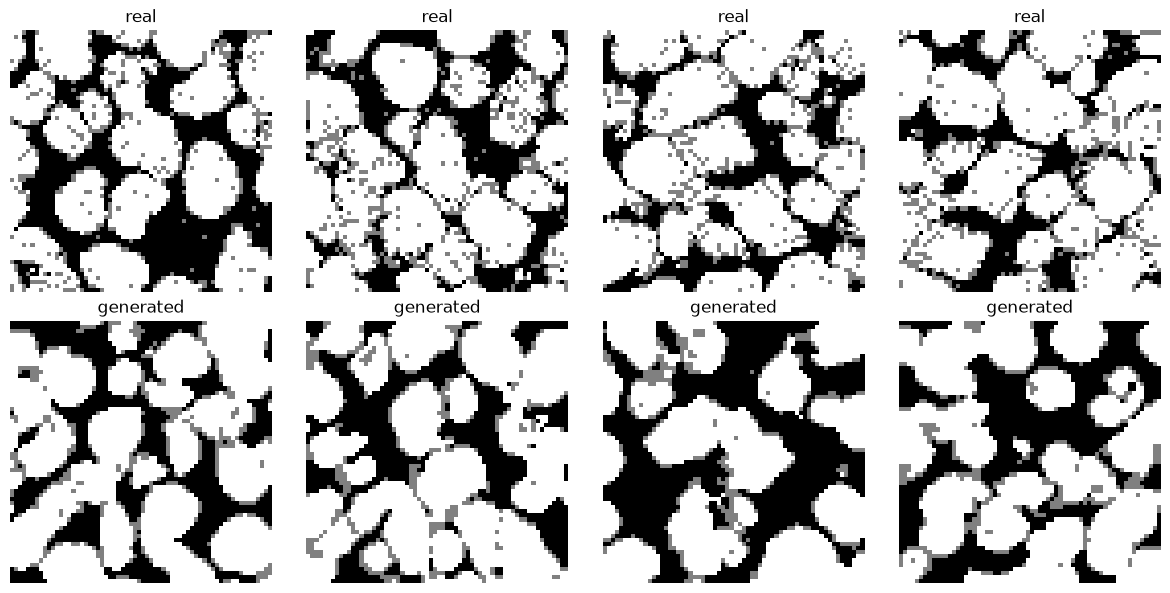

In [9]:
count = min(BATCH_SIZE, 4)
fig, axes = plt.subplots(2, count, figsize=(3 * count, 6), squeeze=False)
for index in range(count):
    axes[0, index].imshow(real_images[index, 0].cpu(), cmap="gray", vmin=0, vmax=args.num_phases - 1, interpolation="nearest")
    axes[0, index].set_title("real")
    axes[1, index].imshow(generated[index, 0].cpu(), cmap="gray", vmin=0, vmax=args.num_phases - 1, interpolation="nearest")
    axes[1, index].set_title("generated")
for axis in axes.ravel():
    axis.axis("off")
plt.tight_layout()

## Diffusion samples ranked by critic

Rank 2D diffusion samples with the GAN critic. A visible separation is a qualitative transfer check, not proof of 3D guidance quality.

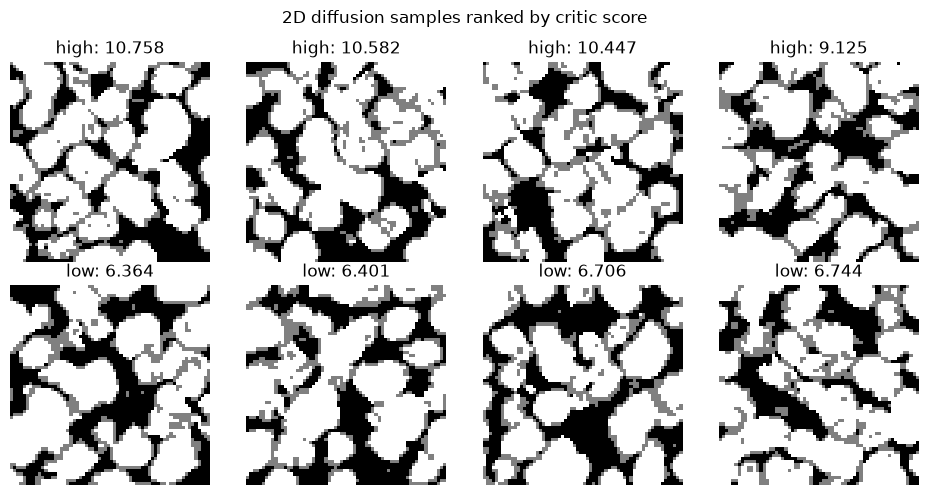

In [10]:
diffusion_vae = diffusion_predictor.vae
shape = (
    DIFFUSION_BATCH_SIZE,
    int(diffusion_vae.latent_ch),
    int(diffusion_vae.latent_size),
    int(diffusion_vae.latent_size),
)
with torch.no_grad():
    diffusion_latent = diffusion_predictor.sampler.sample(shape)
    diffusion_probabilities = diffusion_vae.decode_probs(diffusion_latent)
    diffusion_phase = probabilities_to_calibrated_labels(
        diffusion_probabilities, args.num_phases
    ).cpu()
    critic_scores = critic(diffusion_latent).flatten().cpu()

display_count = min(DISPLAY_COUNT, DIFFUSION_BATCH_SIZE // 2)
order = critic_scores.argsort()
groups = [("high", order[-display_count:].flip(0)), ("low", order[:display_count])]

fig, axes = plt.subplots(
    2, display_count, figsize=(2.4 * display_count, 5), squeeze=False
)
for row, (label, indices) in enumerate(groups):
    for ax, index in zip(axes[row], indices):
        ax.imshow(
            diffusion_phase[index, 0],
            cmap="gray",
            vmin=0,
            vmax=args.num_phases - 1,
            interpolation="nearest",
        )
        ax.set_title(f"{label}: {critic_scores[index]:.3f}")
        ax.axis("off")
plt.suptitle("2D diffusion samples ranked by critic score")
plt.tight_layout()